# TensorFlow Hourly Rainfall Forecasting Using Sensor Data

This notebook trains an MLP rainfall forecasting model for ESP32 deployment from `historical_weather_data_hourly.csv` in the `weather_irrigation_hourly` folder. The model predicts the rainfall amount (in mm) directly from instantaneous weather sensor readings (temperature, humidity, soil temperature, shortwave radiation, and evapotranspiration).

## 1. Imports

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Dropout, Input

tf.keras.utils.set_random_seed(42)
np.random.seed(42)

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'historical_weather_data_hourly.csv'
KERAS_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.keras'
TFLITE_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.tflite'
CC_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.cc'
H_MODEL_PATH = BASE_DIR / 'hourly_rainfall_forecaster.h'
METRICS_PATH = BASE_DIR / 'hourly_rainfall_metrics.json'
FEATURE_COLUMNS_PATH = BASE_DIR / 'hourly_feature_columns.json'
X_MEAN_PATH = BASE_DIR / 'hourly_X_mean.npy'
X_STD_PATH = BASE_DIR / 'hourly_X_std.npy'
Y_AMOUNT_MEAN_PATH = BASE_DIR / 'hourly_y_amount_mean.npy'
Y_AMOUNT_STD_PATH = BASE_DIR / 'hourly_y_amount_std.npy'
RAIN_THRESHOLD_MM = 0.1
C_ARRAY_NAME = 'hourly_rainfall_forecaster_tflite'

FEATURES = [
    'temperature_2m',
    'relative_humidity_2m',
    'soil_temperature_0_to_7cm',
    'shortwave_radiation',
    'et0_fao_evapotranspiration_mm',
]


I0000 00:00:1779203023.107311  756252 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2. Load Data

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        'historical_weather_data_hourly.csv was not found. Run fetch_hourly_weather_data.py first.'
    )

df = pd.read_csv(DATA_PATH, parse_dates=['time'])
df = df.sort_values('time').reset_index(drop=True)
df['precipitation_mm'] = df['precipitation_mm'].clip(lower=0)
df = df.dropna(subset=FEATURES + ['precipitation_mm'])
print(df[['time', 'precipitation_mm'] + FEATURES].head())
print(f'Loaded {len(df):,} hourly rows from {df.time.min()} to {df.time.max()}')


                 time  precipitation_mm  temperature_2m  relative_humidity_2m  \
0 2015-01-01 00:00:00               0.0            15.0                    70   
1 2015-01-01 01:00:00               0.0            14.0                    72   
2 2015-01-01 02:00:00               0.0            13.5                    73   
3 2015-01-01 03:00:00               0.0            13.2                    72   
4 2015-01-01 04:00:00               0.0            12.6                    74   

   soil_temperature_0_to_7cm  shortwave_radiation  \
0                       14.3                  0.0   
1                       13.8                  0.0   
2                       13.4                  0.0   
3                       12.9                  0.0   
4                       12.5                  0.0   

   et0_fao_evapotranspiration_mm  
0                            0.0  
1                            0.0  
2                            0.0  
3                            0.0  
4                  

## 3. Data Exploration

Before feeding the sensor metrics to our model, let's look at how precipitation correlates with our inputs. Understanding these distributions helps confirm whether our inputs carry a signal that the network can learn.

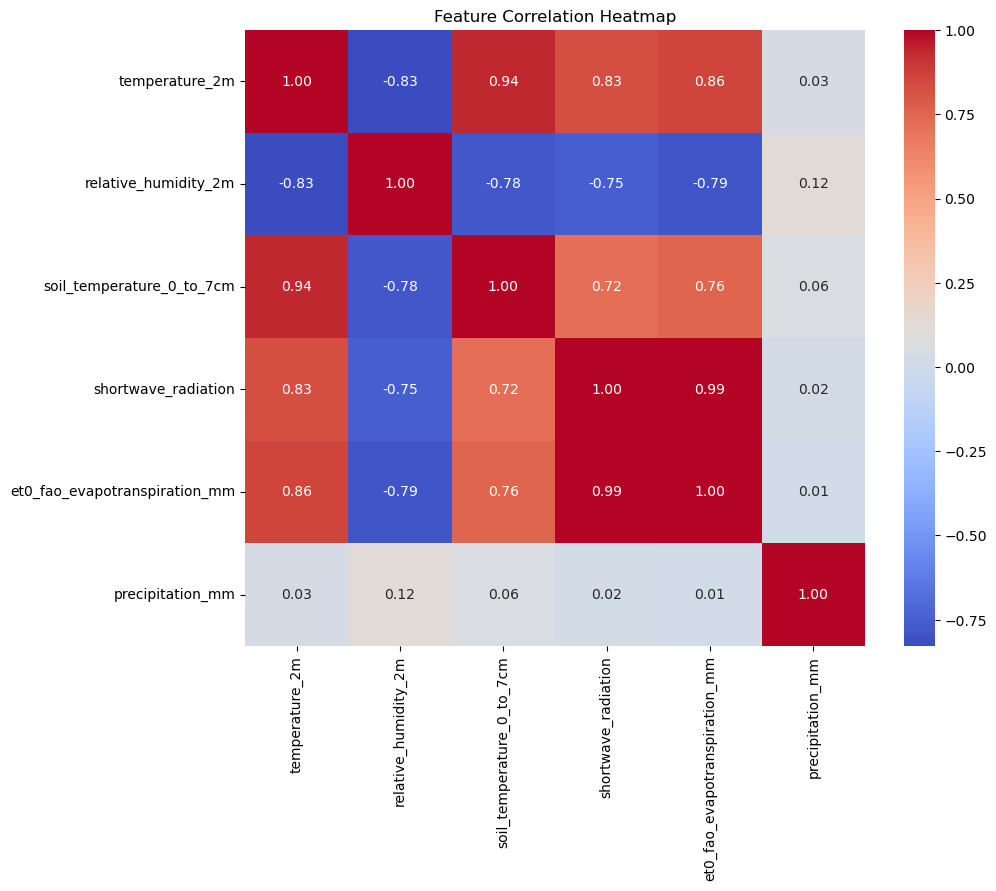

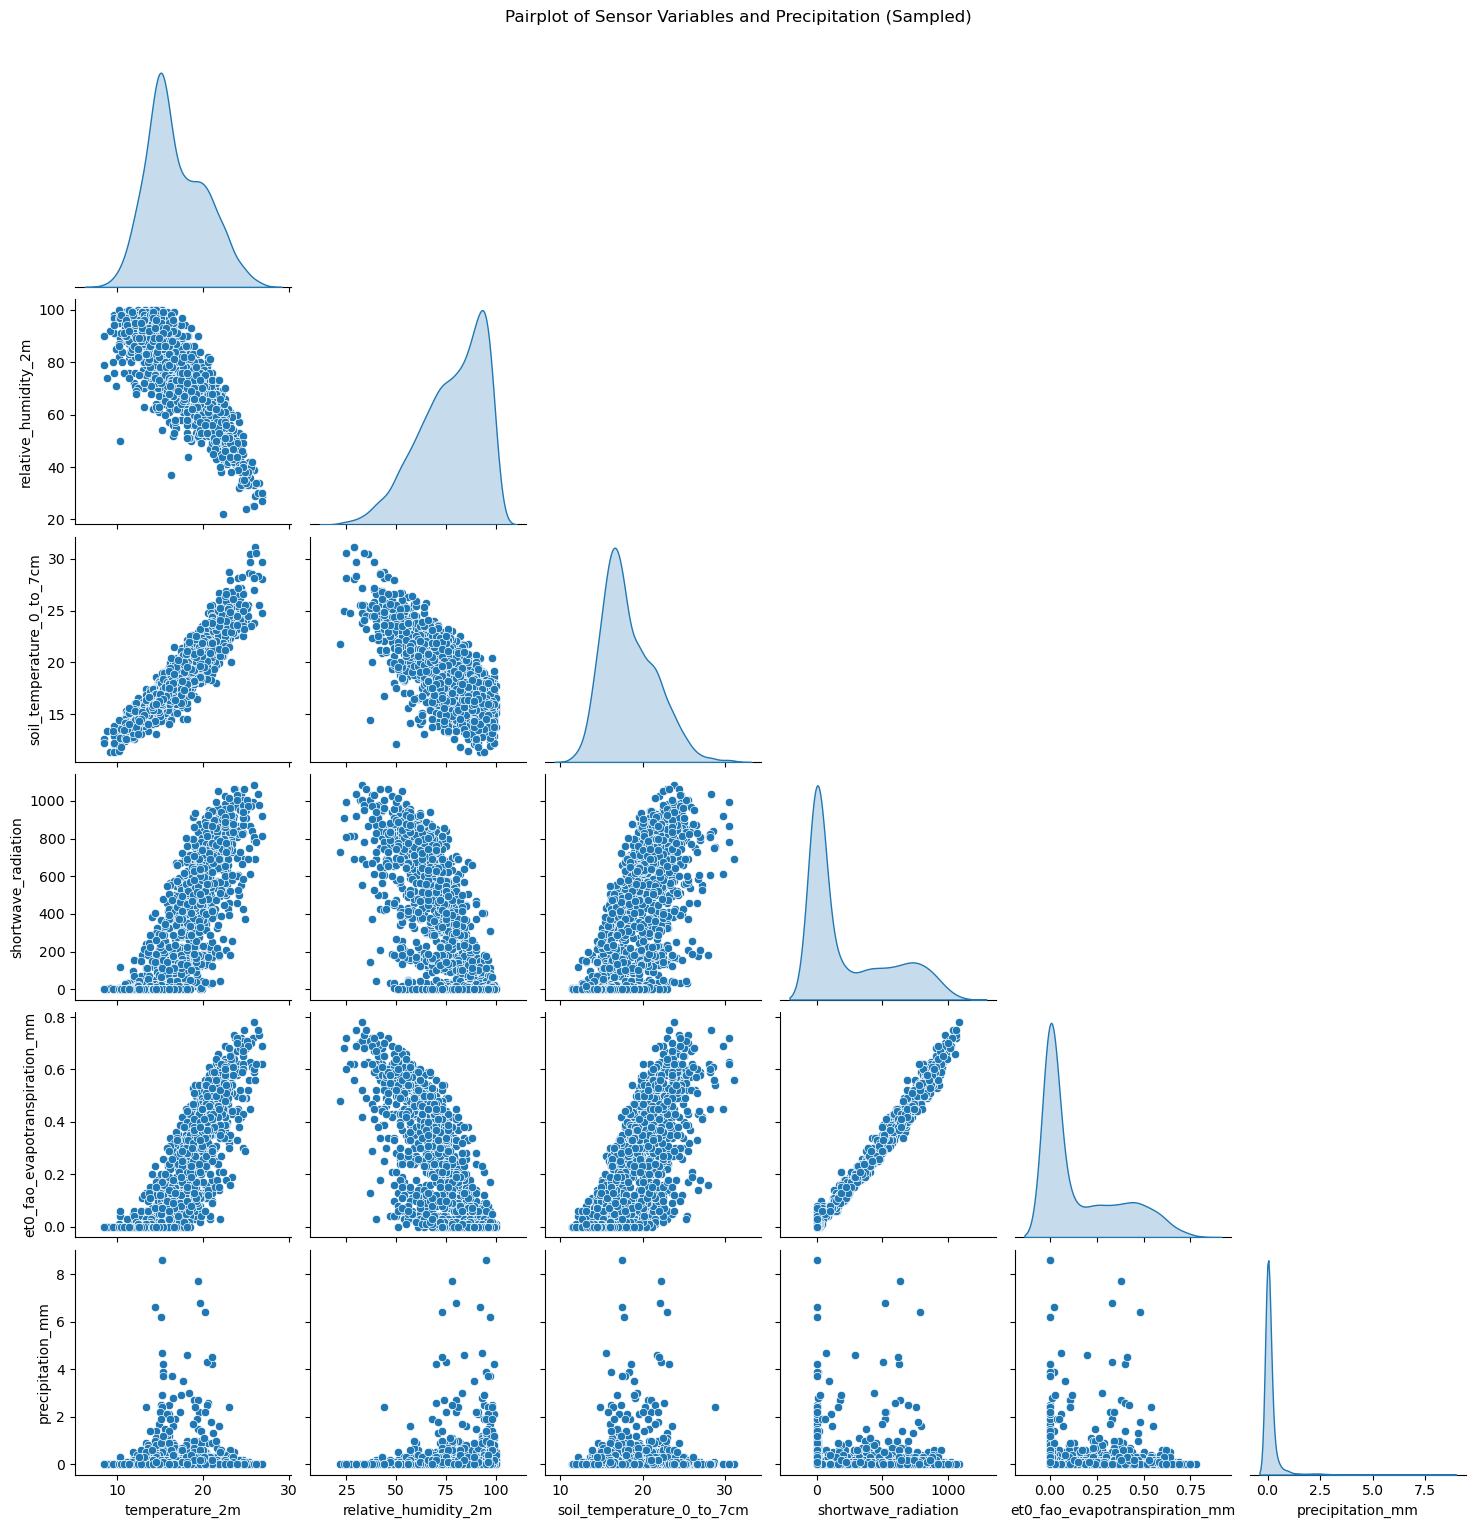

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[FEATURES + ['precipitation_mm']].corr(), annot=True, cmap='coolwarm', ax=ax, fmt='.2f')
ax.set_title('Feature Correlation Heatmap')
plt.show()

sns.pairplot(df[FEATURES + ['precipitation_mm']].sample(n=min(2000, len(df))), corner=True, diag_kind='kde')
plt.suptitle('Pairplot of Sensor Variables and Precipitation (Sampled)', y=1.02)
plt.show()


## 4. Time-Based Split And Scaling

The train-test split is chronological instead of random because forecasting must use the past to predict the future. A random split would leak future seasonal states into training and make evaluation look better than real deployment. Using the first 80% of the timeline for training and the latest 20% for testing gives a more realistic estimate of how the model behaves on unseen future months.

Scaling is fit on the training window only and then reused for the test window. That keeps the preprocessing aligned with deployment, where future data statistics are not known in advance. The target precipitation amount is log-scaled before standardization because hourly rain is highly right-skewed: many dry hours and a small number of heavy-rain events. The log transform compresses those spikes so the regression loss is less dominated by a few extreme hours.

In [4]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[FEATURES].to_numpy(dtype=np.float32)
X_test = test_df[FEATURES].to_numpy(dtype=np.float32)
y_train_amount = train_df['precipitation_mm'].to_numpy(dtype=np.float32)
y_test_amount = test_df['precipitation_mm'].to_numpy(dtype=np.float32)

X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_std[X_std == 0] = 1e-6
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_amount_log = np.log1p(y_train_amount)
y_amount_mean = float(y_train_amount_log.mean())
y_amount_std = float(y_train_amount_log.std())
if y_amount_std == 0:
    y_amount_std = 1e-6
y_train_amount_scaled = ((y_train_amount_log - y_amount_mean) / y_amount_std).astype(np.float32)

np.save(X_MEAN_PATH, X_mean)
np.save(X_STD_PATH, X_std)
np.save(Y_AMOUNT_MEAN_PATH, np.array([y_amount_mean], dtype=np.float32))
np.save(Y_AMOUNT_STD_PATH, np.array([y_amount_std], dtype=np.float32))
FEATURE_COLUMNS_PATH.write_text(json.dumps(FEATURES, indent=2))
print(f'Train rows: {len(train_df):,}, test rows: {len(test_df):,}')
print(f'Feature count: {X_train_scaled.shape[1]}')


Train rows: 77,145, test rows: 19,287
Feature count: 5


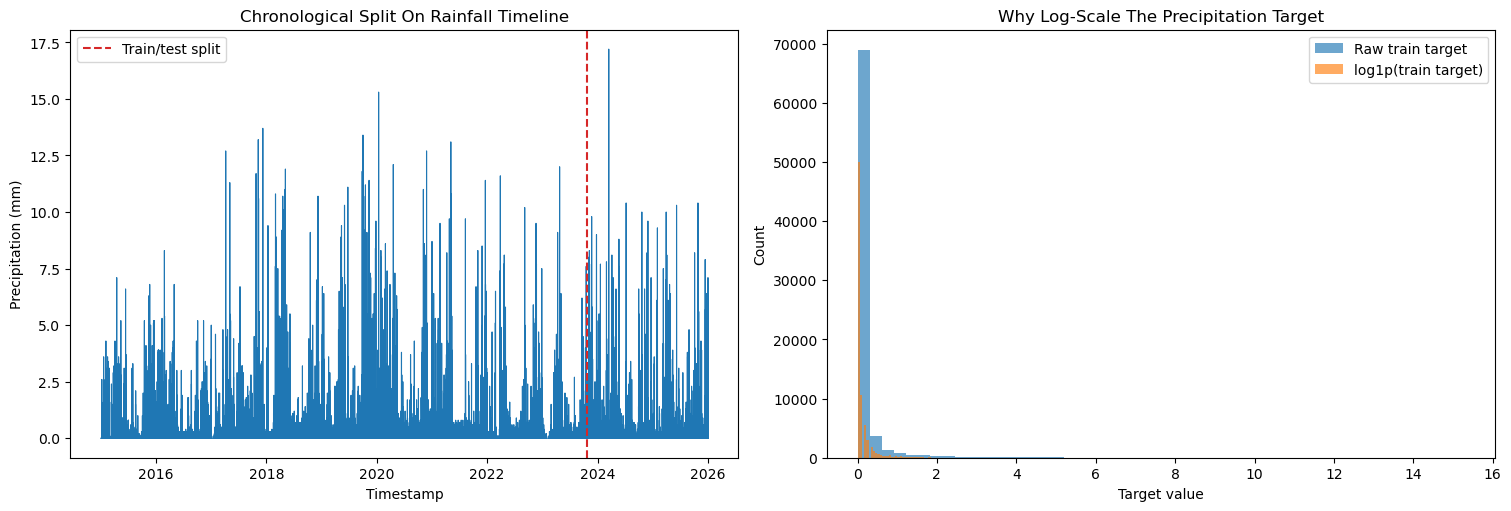

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

axes[0].plot(df['time'], df['precipitation_mm'], color='tab:blue', linewidth=0.8)
axes[0].axvline(df.loc[split_idx, 'time'], color='tab:red', linestyle='--', label='Train/test split')
axes[0].set_title('Chronological Split On Rainfall Timeline')
axes[0].set_xlabel('Timestamp')
axes[0].set_ylabel('Precipitation (mm)')
axes[0].legend()

axes[1].hist(y_train_amount, bins=50, alpha=0.65, label='Raw train target', color='tab:blue')
axes[1].hist(np.log1p(y_train_amount), bins=50, alpha=0.65, label='log1p(train target)', color='tab:orange')
axes[1].set_title('Why Log-Scale The Precipitation Target')
axes[1].set_xlabel('Target value')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.show()



## 5. TensorFlow MLP Model

In [6]:
inputs = Input(shape=(X_train_scaled.shape[1],), name='sensor_features')
x = Dense(32, activation='relu')(inputs)
x = Dense(16, activation='relu')(x)
amount_output = Dense(1, name='amount_output')(x)

model = Model(inputs=inputs, outputs=amount_output)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sensor_features (InputLayer)    │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ amount_output (Dense)           │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Train

In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
]

history = model.fit(
    X_train_scaled,
    y_train_amount_scaled,
    validation_split=0.15,
    epochs=40,
    batch_size=256,
    verbose=1,
    callbacks=callbacks,
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")


Epoch 1/40


  1/257 ━━━━━━━━━━━━━━━━━━━━ 5:35 1s/step - loss: 1.9409

 24/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.3931 

 54/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2441

 83/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1792

...

216/257 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7639

232/257 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7631

248/257 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7623

257/257 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.7486 - val_loss: 0.3838


Training stopped after 40 epochs.
Best val_loss: 0.3835


## 7. Evaluate

In [8]:
amount_pred_scaled = model.predict(X_test_scaled, verbose=0)
amount_pred_scaled = amount_pred_scaled.reshape(-1)
amount_pred = np.expm1((amount_pred_scaled * y_amount_std) + y_amount_mean).clip(min=0)
rainy_mask = y_test_amount >= RAIN_THRESHOLD_MM

def amount_metrics(y_true, y_pred):
    rainy_true = y_true[rainy_mask]
    rainy_pred = y_pred[rainy_mask]
    return {
        'mae_mm': float(mean_absolute_error(y_true, y_pred)),
        'rmse_mm': float(mean_squared_error(y_true, y_pred)**0.5),
        'r2': float(r2_score(y_true, y_pred)),
        'rainy_hours_count': int(rainy_mask.sum()),
        'rainy_mae_mm': float(mean_absolute_error(rainy_true, rainy_pred)) if len(rainy_true) > 0 else 0.0,
        'rainy_rmse_mm': float(mean_squared_error(rainy_true, rainy_pred)**0.5) if len(rainy_true) > 0 else 0.0,
    }

metrics = {
    'train_rows': int(len(train_df)),
    'test_rows': int(len(test_df)),
    'feature_columns': FEATURES,
    'amount_models': {
        'mlp_sensors': amount_metrics(y_test_amount, amount_pred),
    },
    'selected_amount_model': 'mlp_sensors',
}
print(json.dumps(metrics, indent=2))


{
  "train_rows": 77145,
  "test_rows": 19287,
  "feature_columns": [
    "temperature_2m",
    "relative_humidity_2m",
    "soil_temperature_0_to_7cm",
    "shortwave_radiation",
    "et0_fao_evapotranspiration_mm"
  ],
  "amount_models": {
    "mlp_sensors": {
      "mae_mm": 0.15259917080402374,
      "rmse_mm": 0.5145708058128347,
      "r2": 0.19151687622070312,
      "rainy_hours_count": 5832,
      "rainy_mae_mm": 0.3473491072654724,
      "rainy_rmse_mm": 0.9165818471391605
    }
  },
  "selected_amount_model": "mlp_sensors"
}


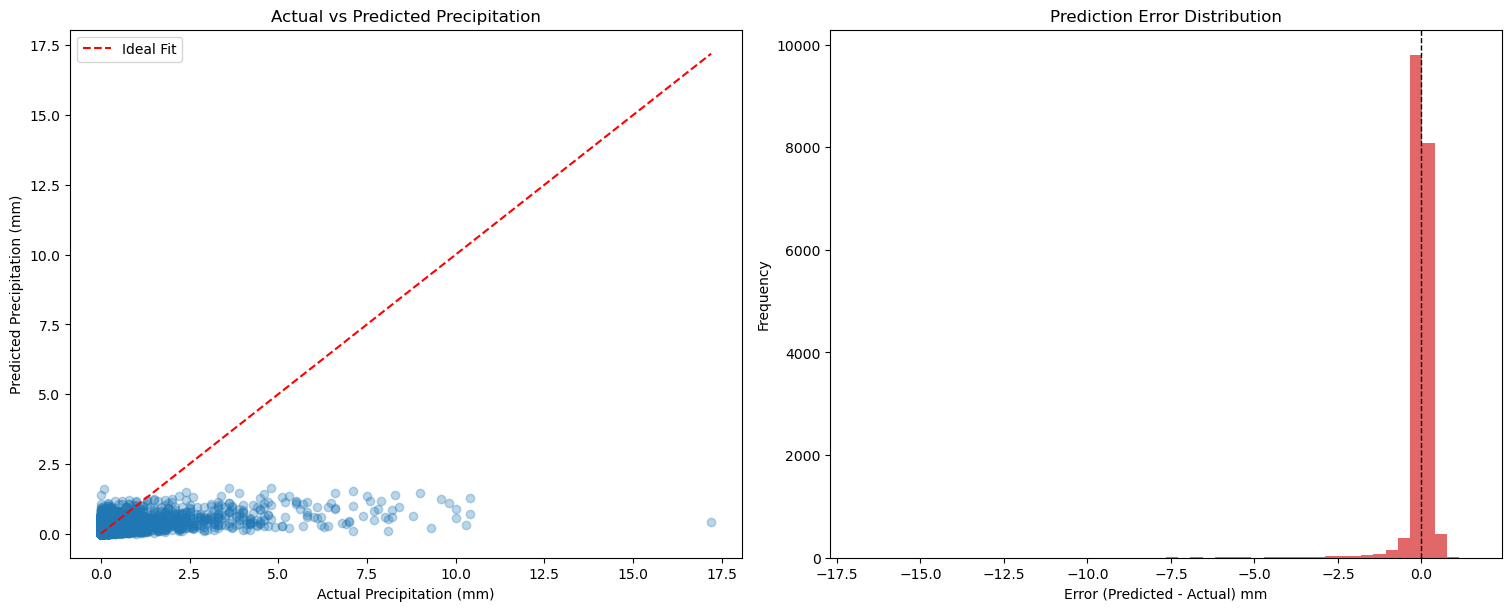

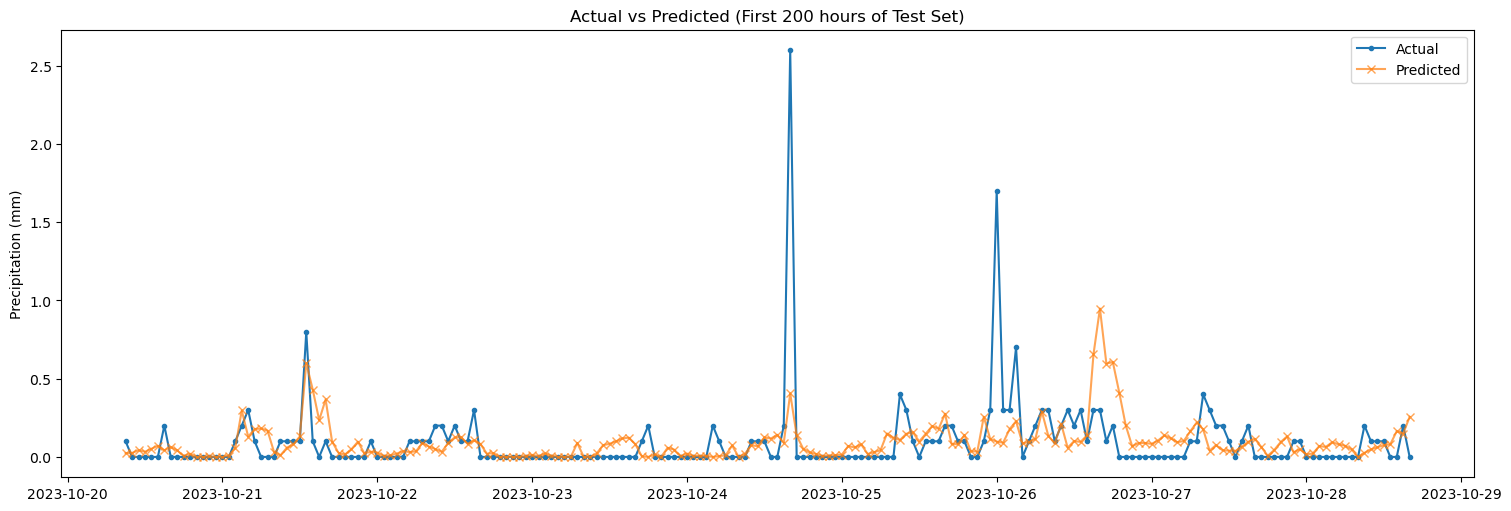

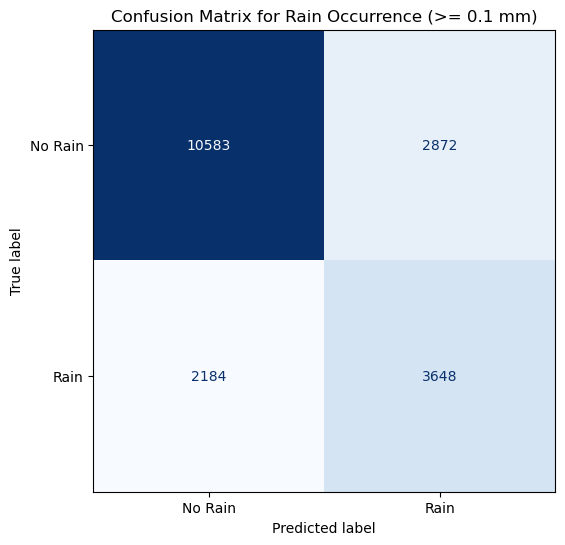

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

axes[0].scatter(y_test_amount, amount_pred, alpha=0.3, color='tab:blue')
axes[0].plot([0, y_test_amount.max()], [0, y_test_amount.max()], 'r--', label='Ideal Fit')
axes[0].set_title('Actual vs Predicted Precipitation')
axes[0].set_xlabel('Actual Precipitation (mm)')
axes[0].set_ylabel('Predicted Precipitation (mm)')
axes[0].legend()

error = amount_pred - y_test_amount
axes[1].hist(error, bins=50, color='tab:red', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='dashed', linewidth=1)
axes[1].set_title('Prediction Error Distribution')
axes[1].set_xlabel('Error (Predicted - Actual) mm')
axes[1].set_ylabel('Frequency')
plt.show()

fig, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
plot_slice = slice(0, 200)
time_slice = test_df['time'].iloc[plot_slice]
ax.plot(time_slice, y_test_amount[plot_slice], label='Actual', marker='.', color='tab:blue')
ax.plot(time_slice, amount_pred[plot_slice], label='Predicted', marker='x', color='tab:orange', alpha=0.7)
ax.set_title('Actual vs Predicted (First 200 hours of Test Set)')
ax.set_ylabel('Precipitation (mm)')
ax.legend()
plt.show()

cm = confusion_matrix(y_test_amount >= RAIN_THRESHOLD_MM, amount_pred >= RAIN_THRESHOLD_MM)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix for Rain Occurrence (>= 0.1 mm)')
plt.show()


## 8. Export Keras, TFLite, And ESP32 Artifacts

In [10]:
def convert_tflite_to_c_array(tflite_path: Path, c_file_path: Path, h_file_path: Path, array_name: str):
    tflite_content = tflite_path.read_bytes()
    hex_array = [f'0x{byte:02x}' for byte in tflite_content]

    with c_file_path.open('w') as c_file:
        c_file.write(f'#include "{h_file_path.name}"\n\n')
        c_file.write(f'const unsigned char {array_name}[] = {{\n')
        for idx in range(0, len(hex_array), 12):
            c_file.write('  ' + ', '.join(hex_array[idx:idx + 12]) + ',\n')
        c_file.write('};\n\n')
        c_file.write(f'const int {array_name}_len = {len(tflite_content)};\n')

    with h_file_path.open('w') as h_file:
        guard = h_file_path.stem.upper() + '_H'
        h_file.write(f'#ifndef {guard}\n')
        h_file.write(f'#define {guard}\n\n')
        h_file.write(f'extern const unsigned char {array_name}[];\n')
        h_file.write(f'extern const int {array_name}_len;\n\n')
        h_file.write(f'#endif  // {guard}\n')

model.save(KERAS_MODEL_PATH)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
TFLITE_MODEL_PATH.write_bytes(tflite_model)
convert_tflite_to_c_array(TFLITE_MODEL_PATH, CC_MODEL_PATH, H_MODEL_PATH, C_ARRAY_NAME)
METRICS_PATH.write_text(json.dumps(metrics, indent=2))

print(f'Saved {KERAS_MODEL_PATH.name}')
print(f'Saved {TFLITE_MODEL_PATH.name} ({len(tflite_model)} bytes)')
print(f'Saved {CC_MODEL_PATH.name}')
print(f'Saved {H_MODEL_PATH.name}')
print(f'Saved {METRICS_PATH.name}')


INFO:tensorflow:Assets written to: /tmp/tmp90ano48k/assets


INFO:tensorflow:Assets written to: /tmp/tmp90ano48k/assets


Saved artifact at '/tmp/tmp90ano48k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5), dtype=tf.float32, name='sensor_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140141446732096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141469696992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141474031056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141474033936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141474034656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140141474031296: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1779203092.004644  756252 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779203092.004666  756252 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779203092.005072  756252 reader.cc:83] Reading SavedModel from: /tmp/tmp90ano48k
I0000 00:00:1779203092.005894  756252 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779203092.005915  756252 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp90ano48k
I0000 00:00:1779203092.018022  756252 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1779203092.019540  756252 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779203092.077690  756252 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp90ano48k
I0000 00:00:1779203092.094645  756252 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 89584 microseconds.
I0000 00:00:1779203092.117157  756252

Saved hourly_rainfall_forecaster.keras
Saved hourly_rainfall_forecaster.tflite (4932 bytes)
Saved hourly_rainfall_forecaster.cc
Saved hourly_rainfall_forecaster.h
Saved hourly_rainfall_metrics.json


## 9. Inference Helper

In [11]:
def forecast_hourly_rainfall(sensor_readings):
    # sensor_readings should be a list of lists matching FEATURES order
    X_future = np.array(sensor_readings, dtype=np.float32)
    X_future_scaled = (X_future - X_mean) / X_std
    amount_scaled = model.predict(X_future_scaled, verbose=0)
    amount_scaled = amount_scaled.reshape(-1)
    amount = np.expm1((amount_scaled * y_amount_std) + y_amount_mean).clip(min=0)
    return pd.DataFrame({
        'predicted_precipitation_mm': amount,
    })

forecast_hourly_rainfall([
    [25.0, 60.0, 24.0, 500.0, 0.5],
    [20.0, 90.0, 19.0, 100.0, 0.1]
])


,predicted_precipitation_mm
0,0.628631
1,0.514381
